### Open an IBM Quantum account on IBM  (https://quantum.cloud.ibm.com/)

##### Legacy IBM Quantum Plattorm (https://quantum.ibm.com) will be accessible until July 1st. We encourage you to migrate to the new platform in case you have an account on classic IQP. 

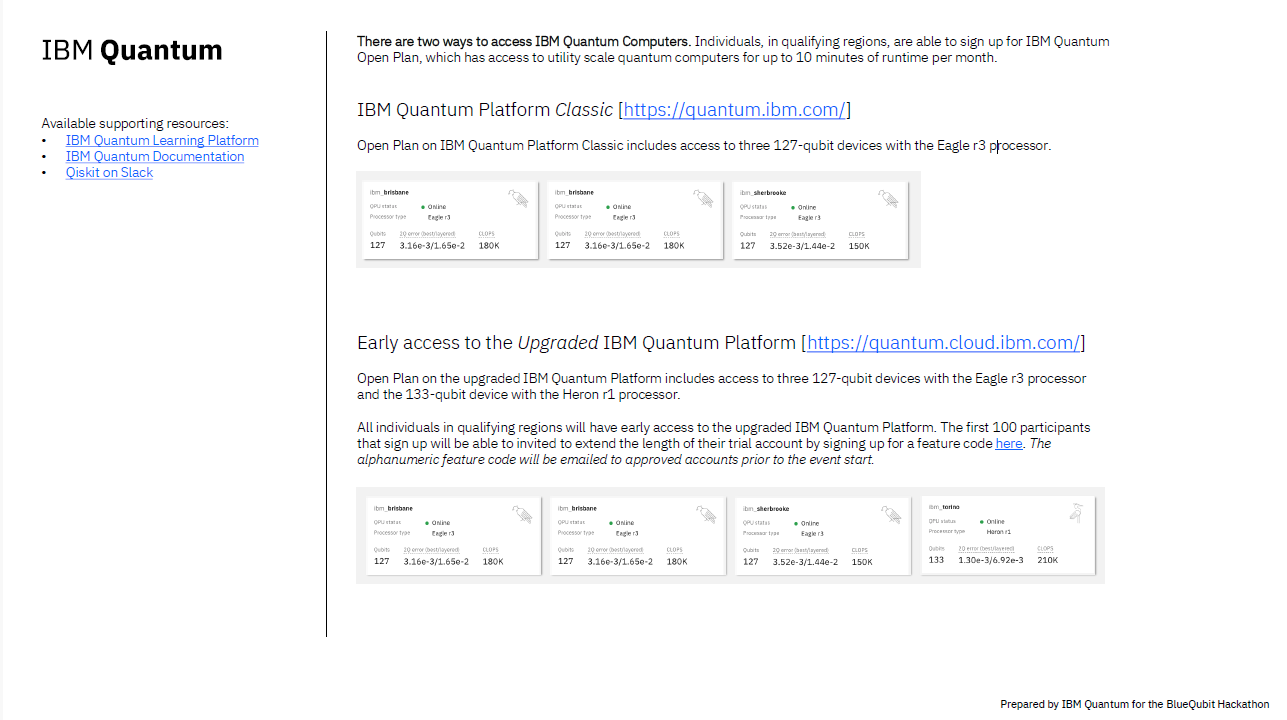

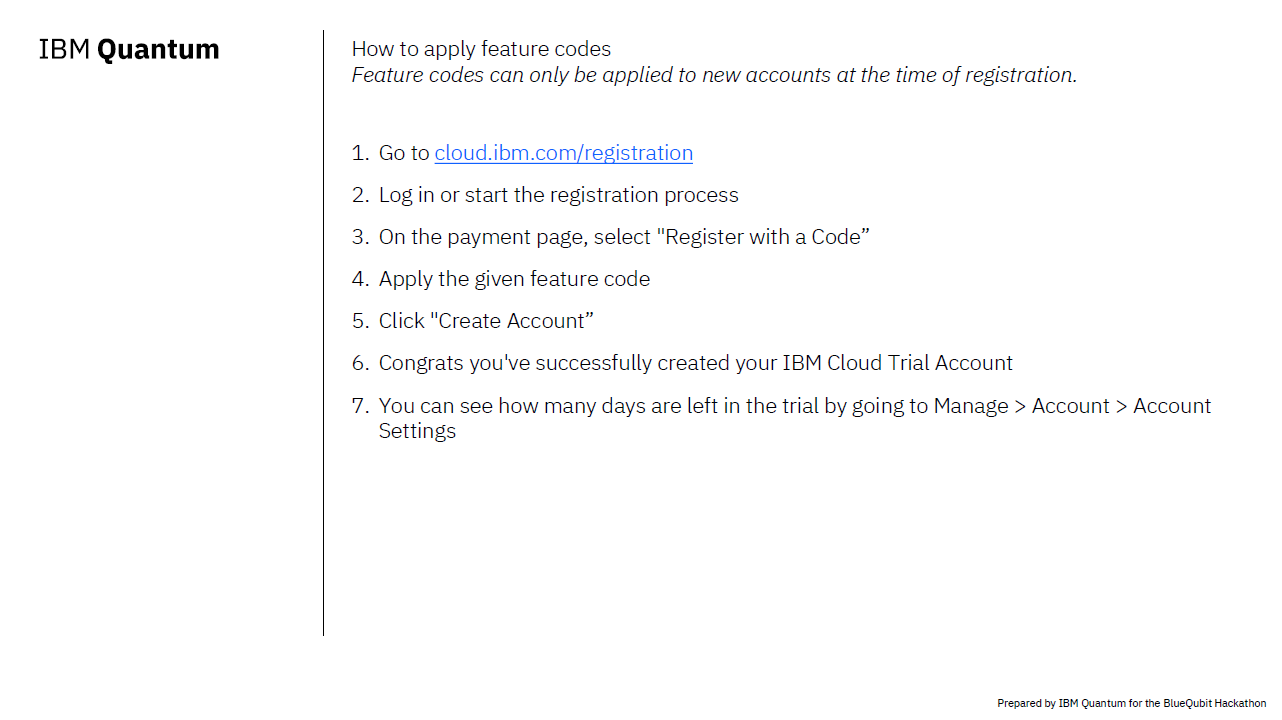

##### After creating an account, go to the top left corner and click Instances. There you can create a new instance from which you'll able to instantiate a backend. In additiona, you will need to create a API Key by clicking "Create API Key" in the top right corner

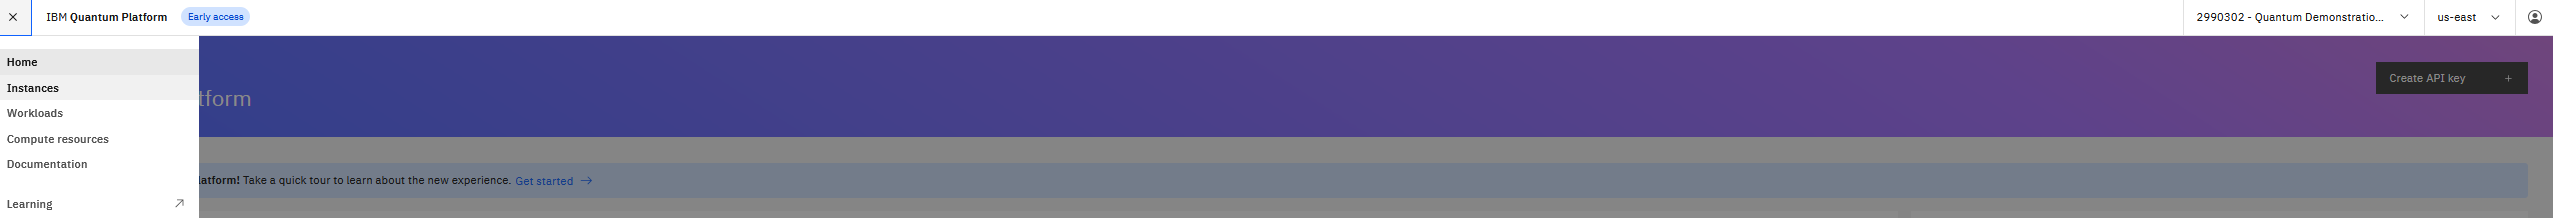

##### After Creating an account, an instance and an API Key, you are ready to connect to a quantum device

In [1]:
from qiskit import qasm, qasm2,qasm3
from qiskit.circuit import QuantumCircuit, ClassicalRegister, Gate, library
from qiskit.transpiler import generate_preset_pass_manager
from qiskit_ibm_runtime import QiskitRuntimeService, Batch, SamplerV2 as Sampler

import numpy as np
from matplotlib import pyplot as plt

In [2]:
## https://github.com/Qiskit/qiskit-ibm-runtime/blob/main/README.md


# We have to instantiate the QiskitRuntimeService in order to access the deivce
# With the devices available to use, we have to pick one where we want to run the circuit on.
backend_name= 'ibm_torino'

service = QiskitRuntimeService(
    channel="ibm_cloud",
    instance=""# (your instance),
    token="", # (your API key),
)

backend = service.backend(backend_name)#,use_fractional_gates=True)

In [3]:
## Load the circuit you would like to run
circuit = QuantumCircuit.from_qasm_file('circuit_28614.qasm')

## In case qasm instructions do not contain measurement instructions, we can add them here
circuit.measure_all()
print(circuit.count_ops())

OrderedDict({'rz': 1680, 'sx': 1120, 'cz': 280, 'measure': 28, 'barrier': 21})


In [4]:
## We have to transpile the circuits to a physical device, device connectivy, basis gate set etc.
## For more details see: https://docs.quantum.ibm.com/api/qiskit/transpiler
optimization_level = 3
pm = generate_preset_pass_manager(optimization_level,
                                  backend=backend)

tp_circuit = pm.run(circuit)

print(tp_circuit.count_ops())
# tp_circuit.draw('mpl', fold=-1, idle_wires=False)

OrderedDict({'rz': 1680, 'sx': 1120, 'cz': 280, 'measure': 28, 'barrier': 21})


#### Run a circuit on a quantum device

In [18]:
sampler = Sampler(backend, options={"default_shots": 100000})

## In sampler we run pubs, which is a collection/list of circuits or tuples of circuits and parameters: https://docs.quantum.ibm.com/api/qiskit/qiskit.primitives.BackendSamplerV2
job = sampler.run([tp_circuit])
print(job.job_id())


cvt3pkva90oc73d4lde0


In [5]:
## we can either retrieved the data directly from the job, or if we have the job_id, we can retrieve it with:
job = service.job('cvt3pkva90oc73d4lde0')
counts = job.result()[0].data.meas.get_counts()

## we sort the count dictionary from highest count to lowest
sorted_cts_dict={k: v for k, v in sorted(counts.items(), key=lambda item: item[1], reverse=True)}

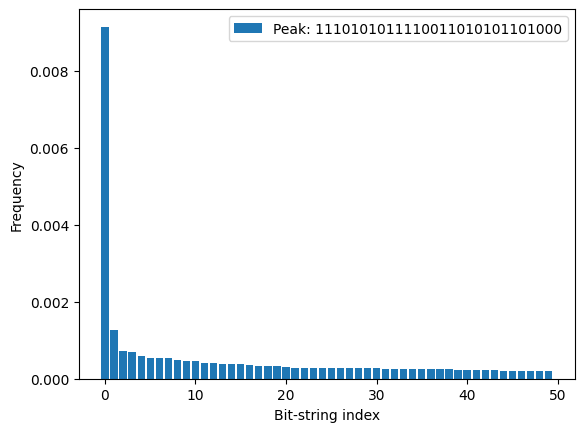

In [6]:
cutoff = 50 #how many bitstrings we want to plot
val_list = list(sorted_cts_dict.values())
string_list = list(sorted_cts_dict.keys())
plt.bar(range(cutoff), np.array(val_list)[0:cutoff]/sum(val_list), label = f"Peak: {string_list[0]}")
plt.ylabel('Frequency')
plt.xlabel('Bit-string index')
plt.legend()
plt.show()


##### The workflow above is a barebones workflow that will get you started. However, there's a lot  one could do to improve the fidelity of the outcomes. A few suggestions one could look into:





- Not all qubits are of equal quality. How would you chose the best qubits:
    - Mapomatic: https://github.com/qiskit-community/mapomatic (basic functionality is implemented in transpiler hgiher optimization level). 
    - Can error model be improved? https://github.com/qiskit-community/qiskit-device-benchmarking
    - Can cost-function be improved?

- Are there better transpilation techniques?
    - different basis gates https://docs.quantum.ibm.com/guides/fractional-gates#fractional-gates
    - can circuits be approximated, shortend etc?

- Current devices are error prone. Can errors be suppressed especially when sampling bitstring distributions
    - https://docs.quantum.ibm.com/guides/error-mitigation-and-suppression-techniques

- Are there error mitigation techniques for sampling? 

These are just a few suggestions to inspire you. 